# 1. Data analysis

Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Load dataset

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,Year,Live births,Deaths,Natural increase,Intermunicipal migration,Immigration to Finland,Emigration from Finland,Net migration,Marriages,Divorces,Total change,Population
0,1970,64559,44119,20440,218979,16824,53205,-36381,40730,6044,-15941,4598336
1,1971,61067,45876,15191,220199,18338,17665,673,37925,7175,27576,4625912
2,1972,58864,43958,14906,234818,17421,11951,5470,35467,8254,27489,4653401
3,1973,56787,43410,13377,246168,16491,10309,6182,34883,8831,25360,4678761
4,1974,62472,44676,17796,276034,13311,12027,1284,34533,10019,23626,4702387


Cleaning - romave spaces

In [3]:
df.columns = df.columns.str.strip()
df = df.sort_values("Year")

Population over time graph

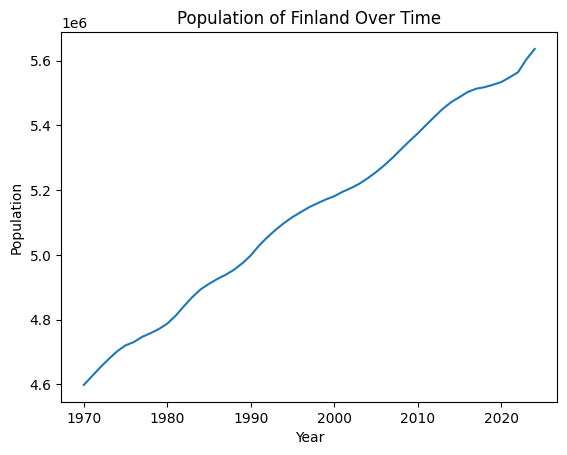

In [4]:
plt.figure()
plt.plot(df["Year"], df["Population"])
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population of Finland Over Time")
plt.show()

Births vs Deaths graph

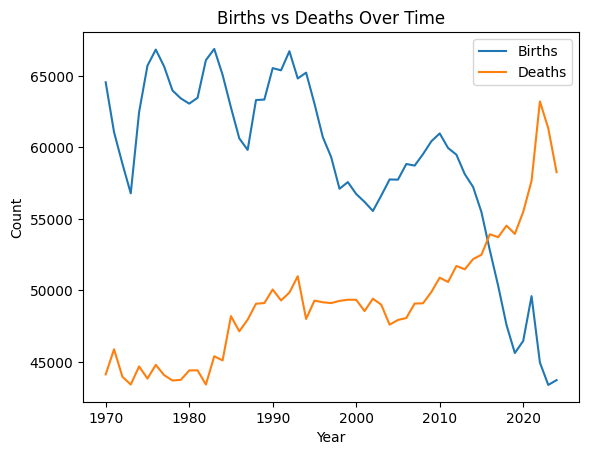

In [5]:
plt.figure()
plt.plot(df["Year"], df["Live births"], label="Births")
plt.plot(df["Year"], df["Deaths"], label="Deaths")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Births vs Deaths Over Time")
plt.show()

Net migration graph

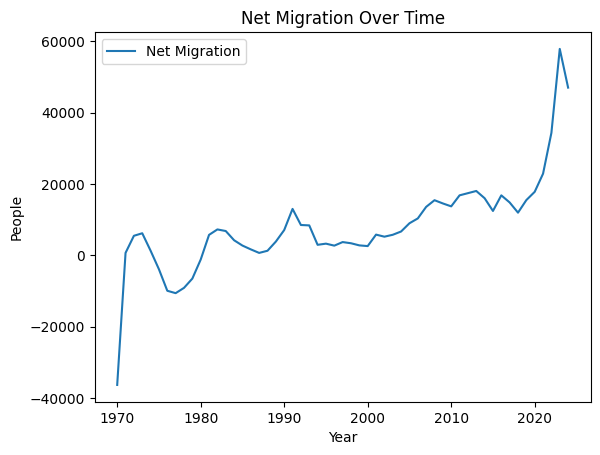

In [6]:
plt.figure()
plt.plot(df["Year"], df["Net migration"], label="Net Migration")
plt.xlabel("Year")
plt.ylabel("People")
plt.title("Net Migration Over Time")
plt.legend()
plt.show()

Natural increase graph

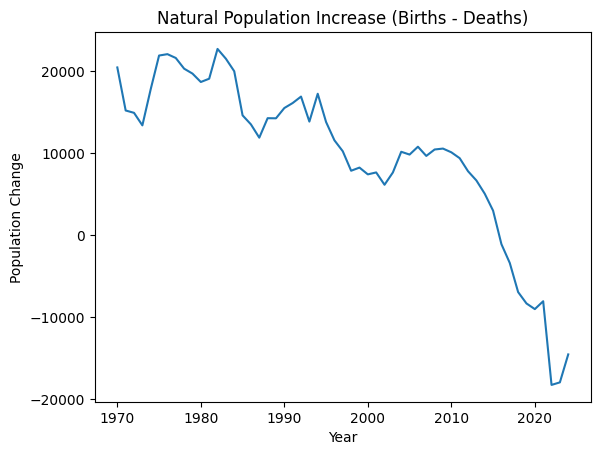

In [7]:
plt.figure()
plt.plot(df["Year"], df["Natural increase"])
plt.xlabel("Year")
plt.ylabel("Population Change")
plt.title("Natural Population Increase (Births - Deaths)")
plt.show()

Compare drivers of the population change graph

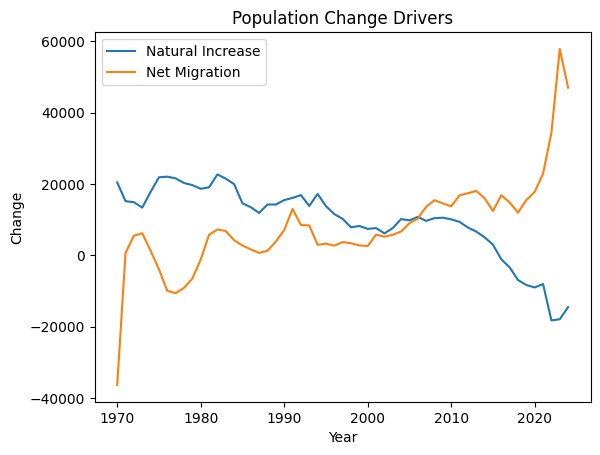

In [8]:
plt.figure()
plt.plot(df["Year"], df["Natural increase"], label="Natural Increase")
plt.plot(df["Year"], df["Net migration"], label="Net Migration")
plt.legend()
plt.title("Population Change Drivers")
plt.xlabel("Year")
plt.ylabel("Change")
plt.show()

Total population change

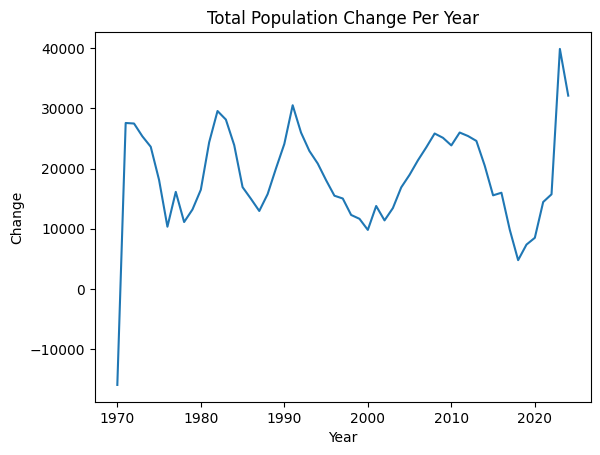

In [9]:
plt.figure()
plt.plot(df["Year"], df["Total change"])
plt.title("Total Population Change Per Year")
plt.xlabel("Year")
plt.ylabel("Change")
plt.show()

Correlation graph 

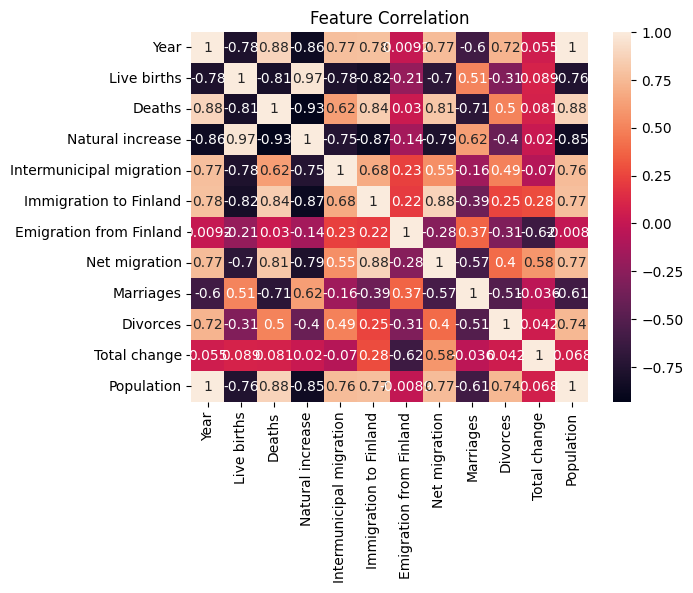

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

# 2. Building model

## 1. run
Firstly, I build a Neural Network model for predicting finnish population in 2030 - 2040 years. </br>
Ofcourse model is not great there is a lot to fix and add.</br>
</br>
Current model predicts population based on this features:
- Year
- Net Migration
- Natural increase    

In [11]:
# --- Imports ---
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

In [12]:
# --- Load data ---
df = pd.read_csv('dataset.csv')
df = df.ffill()

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - loss: 0.7322 - mae: 0.7131 - val_loss: 0.3466 - val_mae: 0.5757
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.4236 - mae: 0.4999 - val_loss: 0.0065 - val_mae: 0.0686
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2339 - mae: 0.3745 - val_loss: 0.0033 - val_mae: 0.0496
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0817 - mae: 0.2277 - val_loss: 0.0224 - val_mae: 0.1383
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1184 - mae: 0.2516 - val_loss: 0.0860 - val_mae: 0.2833
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1049 - mae: 0.2325 - val_loss: 0.1384 - val_mae: 0.3592
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0322 - mae: 0.1312 - val_loss: 0.1122 - val_mae: 0.3202
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0382 - mae: 0.1462 - val_loss: 0.0494 - val_mae: 0.2049
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0457 - mae:

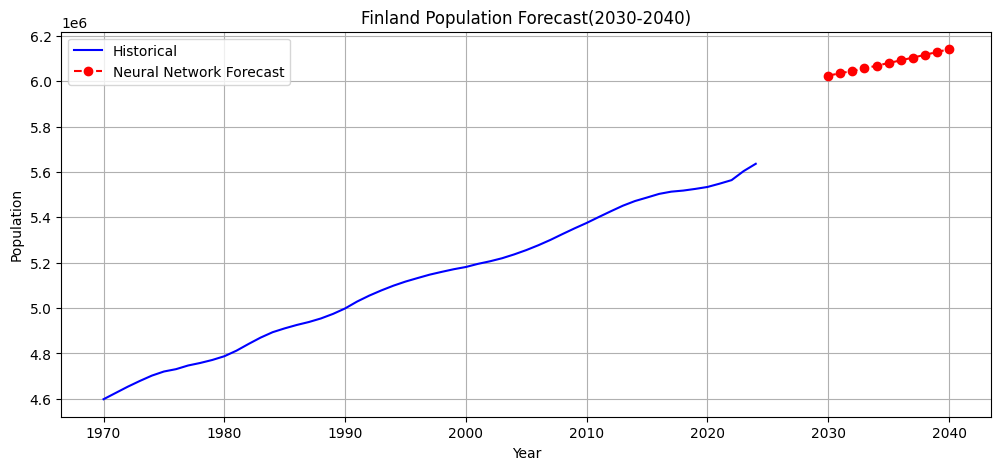

In [13]:
# Prepare features and target
X = df[['Year', 'Net migration', 'Natural increase']].values
y = df['Population'].values

# Split into train/test
train_size = len(df[df['Year'] <= 2014])
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target too
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Build neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

# Early stopping
callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    validation_split=0.2,
    callbacks=[callback],
    verbose=1
)

# Evaluate
loss, mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Test MAE (scaled): {mae:.3f}")

# Predict
future_years = np.arange(2030, 2041)

avg_migration = df[df['Year'] >= 2020]['Net migration'].mean()
avg_natural = df[df['Year'] >= 2020]['Natural increase'].mean()

X_future = np.column_stack([future_years, 
                            [avg_migration] * len(future_years),
                            [avg_natural] * len(future_years)])
X_future_scaled = scaler.transform(X_future)
future_pred_scaled = model.predict(X_future_scaled, verbose=0)
future_pred = scaler_y.inverse_transform(future_pred_scaled)

# Results
print("\n=== FORECAST 2030-2040 ===")
for year, pop in zip(future_years, future_pred.flatten()):
    print(f"{year}: {pop:,.0f}")

#  --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(df['Year'], df['Population'], label='Historical', color='blue')
plt.plot(future_years, future_pred, 'r--o', label='Neural Network Forecast')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Finland Population Forecast(2030-2040)')
plt.legend()
plt.grid(True)
plt.show()

## 2. run
I have added **lag feature**. It is values from previous year, in my case:</br> 
- `population_lag1` is year ago 
- `population_lad2` is two years ago. 
</br>
This feature is nessesary because predictions strongly depens on the data from previous years and relationship between them.</br> 
This feature allows model to understant it. It prevends model from treating each year independently.

I decided to make predictions from 2025 - 2040, because that way it will be easier for model to understand relationship

I also updated prediction methode. Now model uses lag feature. So when it predicts population for 2027 year, it then uses this prediction to predict 2028 and so on.</br> 
This approuche allows model to simulate how population evolves over time. 

### Result
Model works, but backtest is bad and prediction is even worse.

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.8627 - mae: 0.7679 - val_loss: 0.1712 - val_mae: 0.3928
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1905 - mae: 0.3296 - val_loss: 4.2333 - val_mae: 1.9783
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1441 - mae: 0.2702 - val_loss: 4.7026 - val_mae: 2.0501
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1238 - mae: 0.2582 - val_loss: 1.2168 - val_mae: 0.9471
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0189 - mae: 0.1131 - val_loss: 0.3273 - val_mae: 0.3815
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0480 - mae: 0.1790 - val_loss: 0.3053 - val_mae: 0.4128
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0362 - mae: 0.1477 - val_loss: 0.5543 - val_mae: 0.5136
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0299 - mae: 0.1429 - val_loss: 1.3754 - val_mae: 0.8168
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0092 - mae:

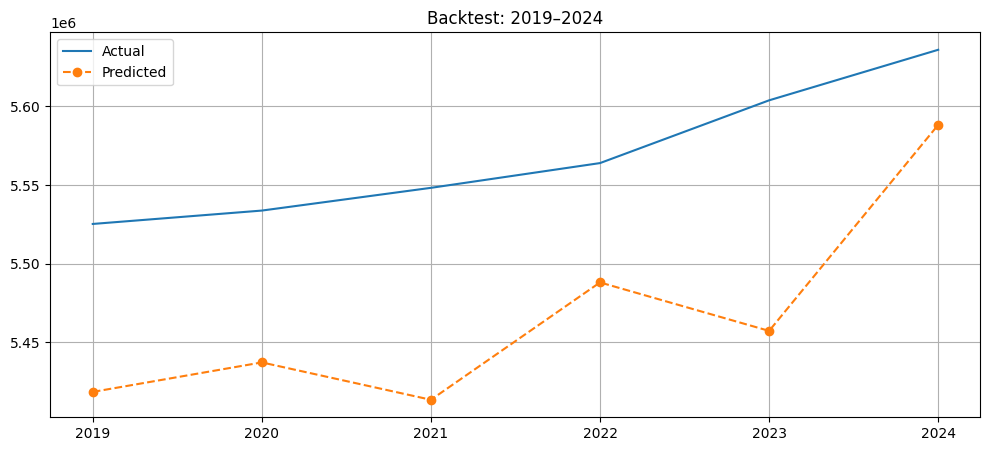

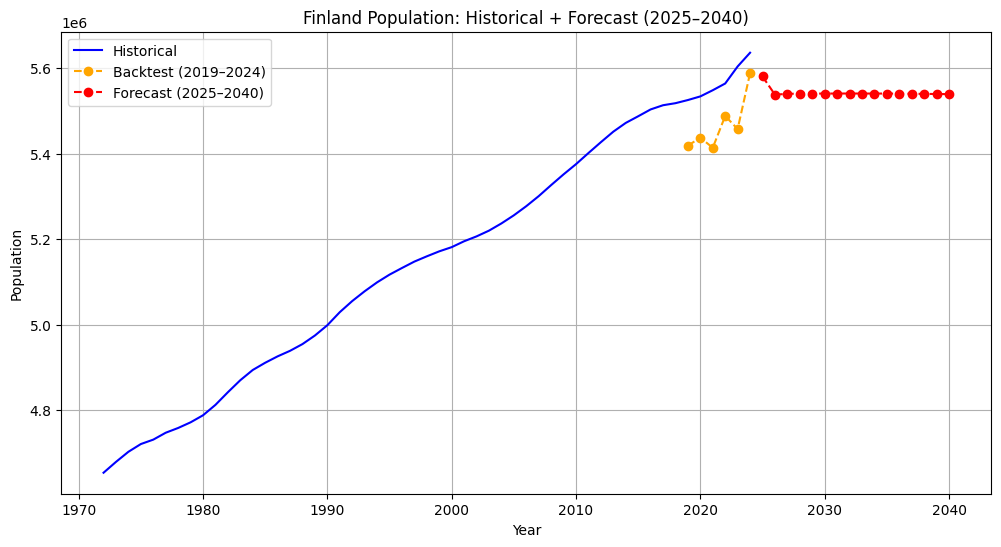

In [14]:
df['Population_lag1'] = df['Population'].shift(1)
df['Population_lag2'] = df['Population'].shift(2)
df['Migration_lag1'] = df['Net migration'].shift(1)
df['Natural_lag1'] = df['Natural increase'].shift(1)

df = df.dropna().reset_index(drop=True)

features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1'
]

X = df[features].values
y = df['Population'].values

# Split into train/test
df_train = df[df['Year'] <= 2018]
df_test = df[(df['Year'] > 2018) & (df['Year'] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['Population'].values
y_test = df_test['Population'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target too
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

# Build neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

# Early stopping
callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_scaled, 
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, scaler_y.transform(y_test.reshape(-1,1)).flatten()),
    callbacks=[callback],
    verbose=1
)

# Predict on test set
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# Predict
future_years = np.arange(2025, 2041)

avg_migration = df[df['Year'] >= 2020]['Net migration'].mean()
avg_natural = df[df['Year'] >= 2020]['Natural increase'].mean()

last_row = df[df['Year'] == 2024].iloc[0]
prev_row = df[df['Year'] == 2023].iloc[0]

current_pop_lag1 = last_row['Population']
current_pop_lag2 = prev_row['Population']

current_migration_lag1 = last_row['Net migration']
current_natural_lag1 = last_row['Natural increase']

future_pred = []

for year in future_years:

    migration = avg_migration
    natural = avg_natural

    X_input = np.array([[
        year,
        migration,
        natural,
        current_pop_lag1,
        current_pop_lag2,
        current_migration_lag1,
        current_natural_lag1
    ]])

    X_scaled = scaler.transform(X_input)

    pred_scaled = model.predict(X_scaled, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled)[0][0]

    future_pred.append(pred)

    current_pop_lag2 = current_pop_lag1
    current_pop_lag1 = pred
    current_migration_lag1 = migration
    current_natural_lag1 = natural


# Results
future_pred = np.array(future_pred)

print("\n=== FORECAST 2030-2040 ===")
for year, pop in zip(future_years, future_pred.flatten()):
    print(f"{year}: {pop:,.0f}")

#  --- Plot backtest---
plt.figure(figsize=(12,5))
plt.plot(df_test['Year'], y_test, label='Actual')
plt.plot(df_test['Year'], y_pred, '--o', label='Predicted')
plt.title('Backtest: 2019–2024')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot forecast ---
plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Population'], label='Historical', color='blue')
plt.plot(df_test['Year'], y_pred, '--o', label='Backtest (2019–2024)', color='orange')
plt.plot(future_years, future_pred, 'r--o', label='Forecast (2025–2040)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Finland Population: Historical + Forecast (2025–2040)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Run
I decided to add delta prediction approach. Idea is that model will predict yearly change in population (delta population) instead of absolut population value. Then population from previous year will be added to the predicted change in population to get population for specific year.</br>
Formula looks like this: **Population(t) = Population(t-1) + Predicted Delta**


### Result
backtest data is very good, I hope it is not overfitting. But forecast plot looks very good too, but it is too straight. I think that is due to small amount of data. I use only years, net nuigration and natural increase.<br> 
Next big step will be adding dataset with age!

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 1.0526 - mae: 0.8838 - val_loss: 2.7757 - val_mae: 1.3252
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.6179 - mae: 0.6443 - val_loss: 3.6871 - val_mae: 1.3675
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.3671 - mae: 0.4896 - val_loss: 8.2890 - val_mae: 2.3985
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1488 - mae: 0.3023 - val_loss: 4.6480 - val_mae: 1.9475
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.3134 - mae: 0.4719 - val_loss: 5.3151 - val_mae: 2.1300
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1746 - mae: 0.3403 - val_loss: 3.8912 - val_mae: 1.7683
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1551 - mae: 0.2941 - val_loss: 1.8907 - val_mae: 1.0167
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1122 - mae: 0.2490 - val_loss: 2.5055 - val_mae: 1.0448
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1006 - mae:

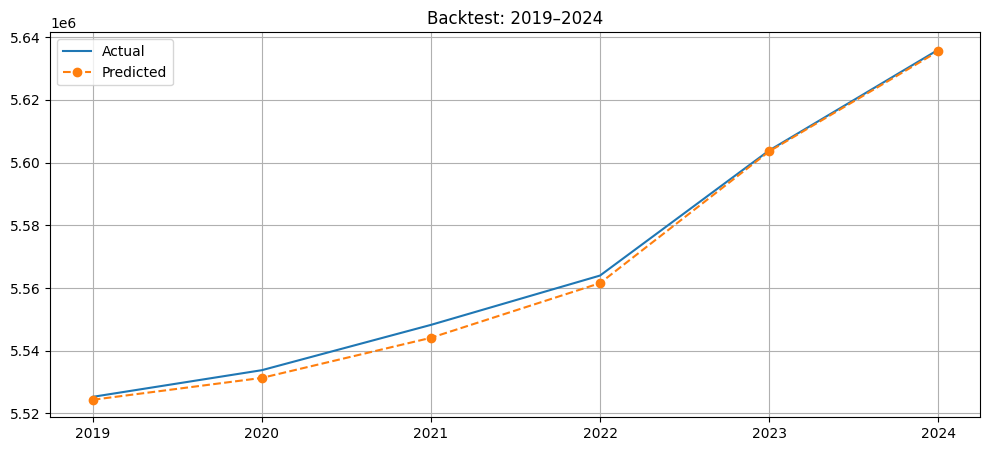

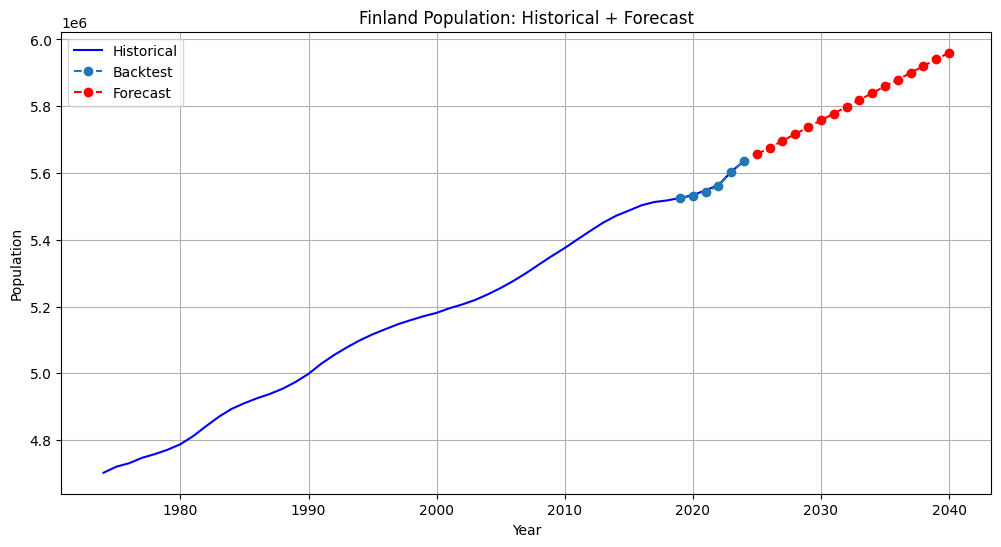

In [15]:
# FEATURES + TARGET
df['Population_lag1'] = df['Population'].shift(1)
df['Population_lag2'] = df['Population'].shift(2)
df['Migration_lag1'] = df['Net migration'].shift(1)
df['Natural_lag1'] = df['Natural increase'].shift(1)

df['Population_delta'] = df['Population'].diff()

df = df.dropna().reset_index(drop=True)

features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1'
]

X = df[features].values
y = df['Population_delta'].values


# SPLIT
df_train = df[df['Year'] <= 2018]
df_test = df[(df['Year'] > 2018) & (df['Year'] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['Population_delta'].values
y_test = df_test['Population_delta'].values


# SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))


# MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)


# TRAIN
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[callback],
    verbose=1
)


# BACKTEST
y_pred_scaled = model.predict(X_test_scaled)

y_pred_delta = scaler_y.inverse_transform(y_pred_scaled).flatten()

test_df = df_test.copy()

reconstructed = []
current_pop = df.loc[df['Year'] == 2018, 'Population'].values[0]

for delta in y_pred_delta:
    current_pop += delta
    reconstructed.append(current_pop)

y_test_real = test_df['Population'].values


# EVALUATION
mae = mean_absolute_error(y_test_real, reconstructed)
print("MAE:", mae)


# FORECAST
future_years = np.arange(2025, 2041)

avg_migration = df['Net migration'].tail(5).mean()
avg_natural = df['Natural increase'].tail(5).mean()

last_row = df[df['Year'] == 2024].iloc[0]
prev_row = df[df['Year'] == 2023].iloc[0]

current_population = last_row['Population']

current_pop_lag1 = last_row['Population']
current_pop_lag2 = prev_row['Population']
current_migration_lag1 = last_row['Net migration']
current_natural_lag1 = last_row['Natural increase']

future_pred = []

for year in future_years:

    X_input = np.array([[
        year,
        avg_migration,
        avg_natural,
        current_pop_lag1,
        current_pop_lag2,
        current_migration_lag1,
        current_natural_lag1
    ]])

    X_scaled = scaler.transform(X_input)

    delta_scaled = model.predict(X_scaled, verbose=0)
    delta = scaler_y.inverse_transform(delta_scaled)[0][0]

    current_population += delta
    future_pred.append(current_population)

    current_pop_lag2 = current_pop_lag1
    current_pop_lag1 = current_population
    current_migration_lag1 = avg_migration
    current_natural_lag1 = avg_natural

future_pred = np.array(future_pred)


# PRINT RESULTS
print("\n=== FORECAST 2025–2040 ===")
for year, pop in zip(future_years, future_pred):
    print(f"{year}: {pop:,.0f}")


# PLOTS
plt.figure(figsize=(12,5))
plt.plot(df_test['Year'], y_test_real, label='Actual')
plt.plot(df_test['Year'], reconstructed, '--o', label='Predicted')
plt.title('Backtest: 2019–2024')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Population'], label='Historical', color='blue')
plt.plot(df_test['Year'], reconstructed, '--o', label='Backtest')
plt.plot(future_years, future_pred, 'r--o', label='Forecast')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Finland Population: Historical + Forecast')
plt.legend()
plt.grid(True)
plt.show()

### 4. Run

This version of the model I have added one more dataset with age of Finnish population by years.</br>
Data is splited into three age groups:</br>
- Youth
- Working age
- Elderly

Each group is treated as separarte feature.</br>
This upgrate is big because now model can learn:
- how population ages
- death rates vary by age
- migration impact is different


Epoch 1/200


C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\1302690141.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Youth"] = df[age_cols[0:20]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\1302690141.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\1302690141.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 1.1061 - mae: 0.8953 - val_loss: 4.0388 - val_mae: 1.6442
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8895 - mae: 0.8194 - val_loss: 2.8633 - val_mae: 1.5341
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8211 - mae: 0.7710 - val_loss: 2.6388 - val_mae: 1.4598
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.6954 - mae: 0.6996 - val_loss: 2.6167 - val_mae: 1.2638
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5389 - mae: 0.6192 - val_loss: 3.2280 - val_mae: 1.2767
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.4190 - mae: 0.5616 - val_loss: 4.0108 - val_mae: 1.3784
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.2977 - mae: 0.4786 - val_loss: 3.2043 - val_mae: 1.2588
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1596 - mae: 0.3300 - val_loss: 1.8157 - val_mae: 0.8624
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1213 - mae: 0.2850 - va

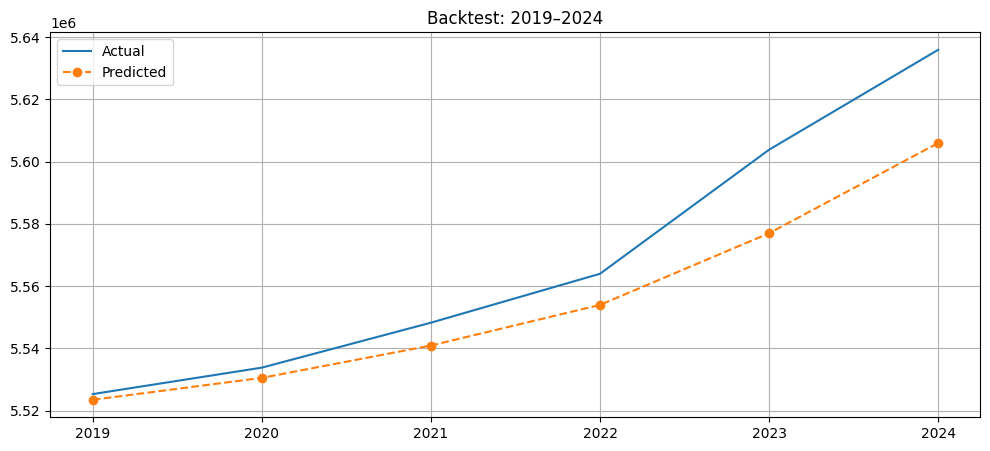

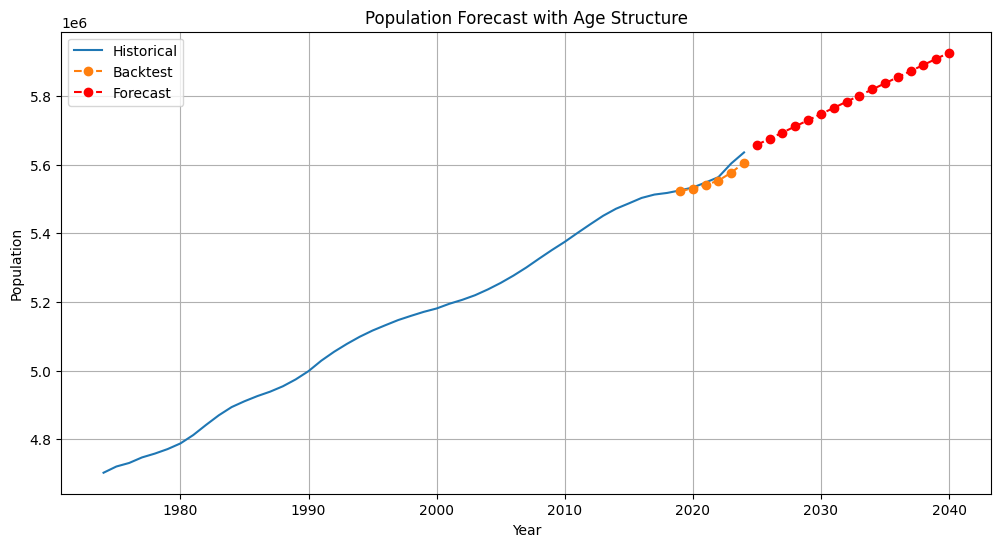


=== FORECAST 2025–2040 ===
2025: 5,657,919
2026: 5,675,940
2027: 5,693,934
2028: 5,711,913
2029: 5,729,877
2030: 5,747,828
2031: 5,765,764
2032: 5,783,686
2033: 5,801,595
2034: 5,819,489
2035: 5,837,370
2036: 5,855,236
2037: 5,873,089
2038: 5,890,927
2039: 5,908,752
2040: 5,926,563


In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")


# 1. PREPARE DATA
df = df.sort_values("Year").reset_index(drop=True)

age_cols = [col for col in df.columns if "Population 31 Dec" in col]

age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))

df["Youth"] = df[age_cols[0:20]].sum(axis=1)
df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
df["Elderly"] = df[age_cols[65:]].sum(axis=1)


df["Dependency_ratio"] = df["Elderly"] / df["Working_Age"]


# 2. FEATURE ENGINEERING
df["Population_lag1"] = df["Population"].shift(1)
df["Population_lag2"] = df["Population"].shift(2)

df["Migration_lag1"] = df["Net migration"].shift(1)
df["Natural_lag1"] = df["Natural increase"].shift(1)

# Target = delta
df["Population_delta"] = df["Population"].diff()

df = df.dropna().reset_index(drop=True)



# 3. FEATURES / TARGET
features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1',
    'Youth',
    'Working_Age',
    'Elderly',
    'Dependency_ratio'
]

X = df[features].values
y = df["Population_delta"].values



# 4. TRAIN / TEST SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[(df["Year"] > 2018) & (df["Year"] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values

y_train = df_train["Population_delta"].values
y_test = df_test["Population_delta"].values



# 5. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))



# 6. MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="mse",
    metrics=["mae"]
)

callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)


# 7. TRAIN
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[callback],
    verbose=1
)


# 8. BACKTEST (2019–2024)
y_pred_scaled = model.predict(X_test_scaled)
y_pred_delta = scaler_y.inverse_transform(y_pred_scaled).flatten()

reconstructed = []
current_pop = df.loc[df["Year"] == 2018, "Population"].values[0]

for delta in y_pred_delta:
    current_pop += delta
    reconstructed.append(current_pop)

y_test_real = df_test["Population"].values

mae = mean_absolute_error(y_test_real, reconstructed)
print("MAE:", mae)


# 9. FORECAST 2025–2040
future_years = np.arange(2025, 2041)

last = df[df["Year"] == 2024].iloc[0]
prev = df[df["Year"] == 2023].iloc[0]

current_population = last["Population"]

pop_lag1 = last["Population"]
pop_lag2 = prev["Population"]

migration_lag1 = last["Net migration"]
natural_lag1 = last["Natural increase"]

youth = last["Youth"]
working = last["Working_Age"]
elderly = last["Elderly"]
dep_ratio = last["Dependency_ratio"]

avg_migration = df["Net migration"].tail(5).mean()
avg_natural = df["Natural increase"].tail(5).mean()

future_pred = []

for year in future_years:

    X_input = np.array([[  
        year,
        avg_migration,
        avg_natural,
        pop_lag1,
        pop_lag2,
        migration_lag1,
        natural_lag1,
        youth,
        working,
        elderly,
        dep_ratio
    ]])

    X_scaled = scaler_X.transform(X_input)

    delta_scaled = model.predict(X_scaled, verbose=0)
    delta = scaler_y.inverse_transform(delta_scaled)[0][0]

    current_population += delta
    future_pred.append(current_population)

    pop_lag2 = pop_lag1
    pop_lag1 = current_population
    migration_lag1 = avg_migration
    natural_lag1 = avg_natural

future_pred = np.array(future_pred)


# 10. PLOTS
plt.figure(figsize=(12,5))
plt.plot(df_test["Year"], y_test_real, label="Actual")
plt.plot(df_test["Year"], reconstructed, "--o", label="Predicted")
plt.title("Backtest: 2019–2024")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df["Year"], df["Population"], label="Historical")
plt.plot(df_test["Year"], reconstructed, "--o", label="Backtest")
plt.plot(future_years, future_pred, "r--o", label="Forecast")
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population Forecast with Age Structure")
plt.legend()
plt.grid(True)
plt.show()


# 11. PRINT FORECAST
print("\n=== FORECAST 2025–2040 ===")
for y, p in zip(future_years, future_pred):
    print(f"{y}: {p:,.0f}")

### 5. Run
To make model even better I have added **dynamic age change**</br>
So model can learn:
- population ages
- there is changes in structure of population, for example more young people who give birth

In the future natural increase can become possitive again 

Epoch 1/200


C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\3702424412.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Youth"] = df[age_cols[0:20]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\3702424412.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\3702424412.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.9946 - mae: 0.8428 - val_loss: 2.8666 - val_mae: 1.4777
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.7204 - mae: 0.7133 - val_loss: 2.4776 - val_mae: 1.3666
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.5468 - mae: 0.6095 - val_loss: 2.0655 - val_mae: 1.2245
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4123 - mae: 0.5109 - val_loss: 1.7022 - val_mae: 0.9903
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2934 - mae: 0.4081 - val_loss: 1.6598 - val_mae: 0.9207
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2025 - mae: 0.3483 - val_loss: 1.8438 - val_mae: 0.9839
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1208 - mae: 0.2706 - val_loss: 1.7344 - val_mae: 1.0972
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1164 - mae: 0.2488 - val_loss: 1.7682 - val_mae: 1.2424
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0882 - mae: 0.2461 - va

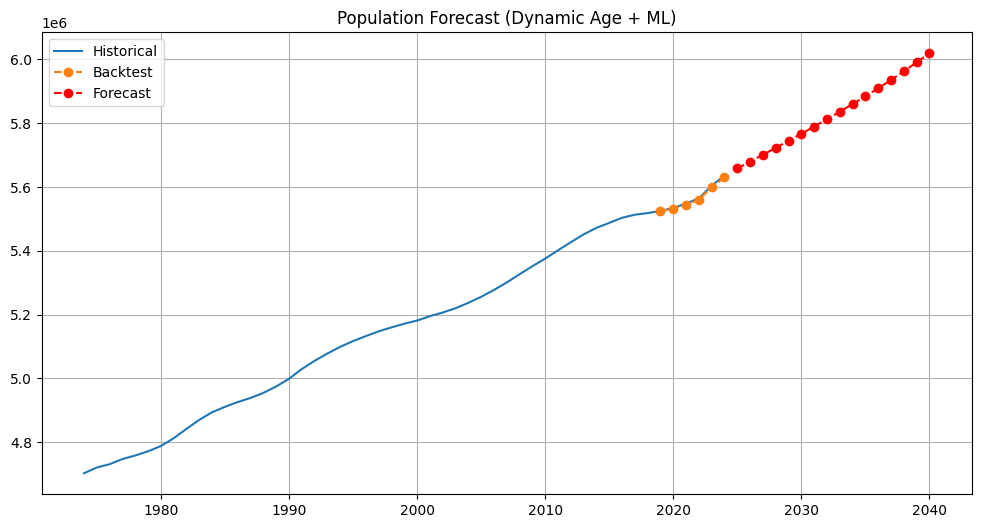


=== FORECAST 2025–2040 ===
2025: 5,657,992
2026: 5,679,418
2027: 5,700,944
2028: 5,722,645
2029: 5,744,540
2030: 5,766,668
2031: 5,789,358
2032: 5,812,524
2033: 5,835,985
2034: 5,859,790
2035: 5,884,174
2036: 5,909,362
2037: 5,935,385
2038: 5,962,707
2039: 5,990,677
2040: 6,019,106


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


# 1. LOAD + MERGE DATA
df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")
df = df.sort_values("Year").reset_index(drop=True)


# 2. AGE COLUMNS
age_cols = [col for col in df.columns if "Population 31 Dec" in col]
age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))



# 3. COMPRESS AGE STRUCTURE
df["Youth"] = df[age_cols[0:20]].sum(axis=1)
df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
df["Elderly"] = df[age_cols[65:]].sum(axis=1)

df["Dependency_ratio"] = df["Elderly"] / df["Working_Age"]


# 4. FEATURE ENGINEERING
df["Population_lag1"] = df["Population"].shift(1)
df["Population_lag2"] = df["Population"].shift(2)

df["Migration_lag1"] = df["Net migration"].shift(1)
df["Natural_lag1"] = df["Natural increase"].shift(1)

df["Population_delta"] = df["Population"].diff()

df = df.dropna().reset_index(drop=True)


# 5. FEATURES / TARGET
features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1',
    'Youth',
    'Working_Age',
    'Elderly',
    'Dependency_ratio'
]


# 6. TRAIN / TEST SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[(df["Year"] > 2018) & (df["Year"] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values

y_train = df_train["Population_delta"].values
y_test = df_test["Population_delta"].values



# 7. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))


# 8. MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="mse",
    metrics=["mae"]
)

callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

# 9. TRAIN
model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[callback],
    verbose=1
)


# 10. BACKTEST
y_pred_scaled = model.predict(X_test_scaled)
y_pred_delta = scaler_y.inverse_transform(y_pred_scaled).flatten()

reconstructed = []
current_pop = df.loc[df["Year"] == 2018, "Population"].values[0]

for delta in y_pred_delta:
    current_pop += delta
    reconstructed.append(current_pop)

mae = mean_absolute_error(df_test["Population"], reconstructed)
print("MAE:", mae)


# 11. AGE MODEL SETUP
ages = np.arange(len(age_cols))
age_state = df[df["Year"] == 2024][age_cols].values[0].astype(float)

mortality_rate = np.zeros(len(ages))
for age in ages:
    if age < 1:
        mortality_rate[age] = 0.003
    elif age < 15:
        mortality_rate[age] = 0.0005
    elif age < 40:
        mortality_rate[age] = 0.001
    elif age < 65:
        mortality_rate[age] = 0.005
    elif age < 80:
        mortality_rate[age] = 0.02
    else:
        mortality_rate[age] = 0.08

fertility_rate = np.zeros(len(ages))
for age in range(15, 50):
    fertility_rate[age] = 0.04

avg_migration = df["Net migration"].tail(5).mean()
avg_natural = df["Natural increase"].tail(5).mean()

migration = np.zeros(len(ages))
migration[20:45] = avg_migration / 25

def simulate_year(state):
    new_state = np.zeros_like(state)

    for age in range(len(state) - 1, 0, -1):
        new_state[age] = state[age - 1] * (1 - mortality_rate[age - 1])

    births = np.sum(state * fertility_rate)
    new_state[0] = births

    new_state += migration

    return new_state


# 12. FORECAST (DYNAMIC AGE)
future_years = np.arange(2025, 2041)

last = df[df["Year"] == 2024].iloc[0]
prev = df[df["Year"] == 2023].iloc[0]

current_population = last["Population"]

pop_lag1 = last["Population"]
pop_lag2 = prev["Population"]

migration_lag1 = last["Net migration"]
natural_lag1 = last["Natural increase"]

current_state = age_state.copy()

future_pred = []

for year in future_years:
    current_state = simulate_year(current_state)

    youth = np.sum(current_state[0:20])
    working = np.sum(current_state[20:65])
    elderly = np.sum(current_state[65:])
    dep_ratio = elderly / working if working > 0 else 0

    X_input = np.array([[  
        year,
        avg_migration,
        avg_natural,
        pop_lag1,
        pop_lag2,
        migration_lag1,
        natural_lag1,
        youth,
        working,
        elderly,
        dep_ratio
    ]])

    X_scaled = scaler_X.transform(X_input)

    delta_scaled = model.predict(X_scaled, verbose=0)
    delta = scaler_y.inverse_transform(delta_scaled)[0][0]

    current_population += delta
    future_pred.append(current_population)

    pop_lag2 = pop_lag1
    pop_lag1 = current_population
    migration_lag1 = avg_migration
    natural_lag1 = avg_natural

future_pred = np.array(future_pred)


# 13. PLOTS
plt.figure(figsize=(12,6))
plt.plot(df["Year"], df["Population"], label="Historical")
plt.plot(df_test["Year"], reconstructed, "--o", label="Backtest")
plt.plot(future_years, future_pred, "r--o", label="Forecast")
plt.legend()
plt.grid(True)
plt.title("Population Forecast (Dynamic Age + ML)")
plt.show()


# 14. OUTPUT
print("\n=== FORECAST 2025–2040 ===")
for y, p in zip(future_years, future_pred):
    print(f"{y}: {p:,.0f}")

### 6. Run
Last model works fine, but I have noticed that even tho I make big changes like adding age groups, dynamic age, etc.</br>
Results doesn't change a lot, thats because first features that I implemented:
- population_lag
- migration is static
- natural increase is static

This features give too big affect on the model, because of that even after adding age groups model doesn't rely on it.</br>
I am interested what results I will get if I will:
- delete `lag feature`
- make `migration` trend based
- make `natural change`: births - deaths

This should make model behave more realisticly


C:\Users\rolan\AppData\Local\Temp\ipykernel_22132\649324329.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Births"] = df["Live births"]


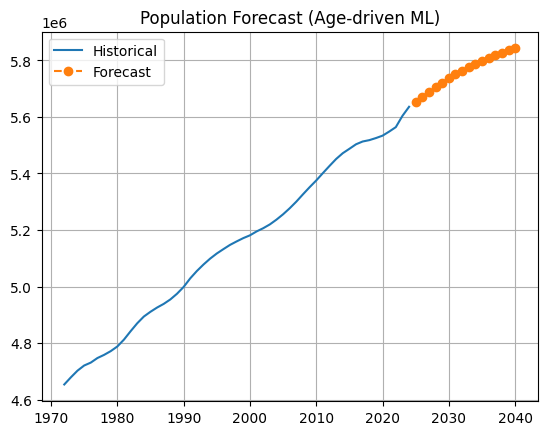


=== FORECAST ===
2025: 5,654,009
2026: 5,672,099
2027: 5,689,382
2028: 5,705,689
2029: 5,721,199
2030: 5,736,080
2031: 5,750,471
2032: 5,764,007
2033: 5,776,618
2034: 5,788,526
2035: 5,799,668
2036: 5,809,978
2037: 5,819,426
2038: 5,828,028
2039: 5,835,671
2040: 5,842,264


In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


# 1. LOAD DATA
df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")
df = df.sort_values("Year").reset_index(drop=True)


# 2. AGE FEATURES
age_cols = [c for c in df.columns if "Population 31 Dec" in c]
age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))

age_features = pd.DataFrame({
    "Youth": df[age_cols[0:20]].sum(axis=1),
    "Working_Age": df[age_cols[20:65]].sum(axis=1),
    "Elderly": df[age_cols[65:]].sum(axis=1),
})

age_features["Dependency_ratio"] = age_features["Elderly"] / age_features["Working_Age"]

df = pd.concat([df, age_features], axis=1)


# 3. TARGETS
df["Births"] = df["Live births"]
df["Deaths"] = df["Deaths"]


# 4. FEATURES (NO LAGS)
features = [
    "Year",
    "Youth",
    "Working_Age",
    "Elderly",
    "Dependency_ratio"
]


# 5. TRAIN SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[df["Year"] > 2018]

X_train = df_train[features].values
X_test = df_test[features].values

y_birth_train = df_train["Births"].values
y_death_train = df_train["Deaths"].values



# 6. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)

scaler_birth = StandardScaler()
y_birth_scaled = scaler_birth.fit_transform(y_birth_train.reshape(-1,1))

scaler_death = StandardScaler()
y_death_scaled = scaler_death.fit_transform(y_death_train.reshape(-1,1))



# 7. MODELS
def build_model():
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(features),)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

model_birth = build_model()
model_death = build_model()



# 8. TRAIN
model_birth.fit(X_train_scaled, y_birth_scaled, epochs=150, verbose=0)
model_death.fit(X_train_scaled, y_death_scaled, epochs=150, verbose=0)


# 9. MIGRATION TREND MODEL
trend_model = LinearRegression()
trend_model.fit(df[["Year"]], df["Net migration"])



# 10. AGE DYNAMICS SETUP
ages = np.arange(len(age_cols))
state = df[df["Year"] == 2024][age_cols].values[0].astype(float)

mortality_rate = np.zeros(len(ages))
for age in ages:
    if age < 1:
        mortality_rate[age] = 0.003
    elif age < 15:
        mortality_rate[age] = 0.0005
    elif age < 40:
        mortality_rate[age] = 0.001
    elif age < 65:
        mortality_rate[age] = 0.005
    elif age < 80:
        mortality_rate[age] = 0.02
    else:
        mortality_rate[age] = 0.08

def simulate_year(state):
    new = np.zeros_like(state)

    for age in range(len(state)-1,0,-1):
        new[age] = state[age-1]*(1-mortality_rate[age-1])

    return new



# 11. FORECAST
years = np.arange(2025, 2041)
population = df[df["Year"]==2024]["Population"].values[0]

future_pop = []
current_state = state.copy()

for year in years:

    current_state = simulate_year(current_state)

    youth = np.sum(current_state[0:20])
    working = np.sum(current_state[20:65])
    elderly = np.sum(current_state[65:])
    dep = elderly / working if working > 0 else 0

    X_input = scaler_X.transform([[year, youth, working, elderly, dep]])

    births = scaler_birth.inverse_transform(
        model_birth.predict(X_input, verbose=0)
    )[0][0]

    deaths = scaler_death.inverse_transform(
        model_death.predict(X_input, verbose=0)
    )[0][0]

    migration = trend_model.predict(pd.DataFrame({"Year": [year]}))[0]

    population = population + births - deaths + migration
    future_pop.append(population)



# 12. RESULTS
plt.plot(df["Year"], df["Population"], label="Historical")
plt.plot(years, future_pop, "--o", label="Forecast")
plt.legend()
plt.grid()
plt.title("Population Forecast (Age-driven ML)")
plt.show()

print("\n=== FORECAST ===")
for y, p in zip(years, future_pop):
    print(f"{y}: {p:,.0f}")